# Feature Engineering

This notebook derives higher-level, interpretable features from the preprocessed dataset. It focuses on regime/state representations for macro, fundamentals, and technicals, and validates their coherence before target construction.

## Basic Setup

### Imports and Paths

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

IN_PREP_PATH = "../data/processed/financial_database_preprocessed.parquet"
OUT_FEAT_PATH = "../data/processed/financial_database_features.parquet"

### Load Preprocessed Dataset

The preprocessed dataset from the prior step is loaded as the stable base for feature engineering to ensure consistency and reproducibility.

In [ ]:
df_prep = pd.read_parquet(IN_PREP_PATH)
print("Shape:", df_prep.shape)
display(df_prep.head(3))

Shape: (27650, 37)


,date,open,high,low,close,adj_close,volume,sma_50,sma_200,ema_20,price_sma_50,rsi_14,macd,macd_signal,volatility_20d,ret_1d,ret_5d,ret_21d,net_margin,operating_margin,ebitda_margin,asset_turnover,roe,roa,fcf_margin,revenue_growth_qoq,earnings_growth_qoq,fcf_growth_qoq,debt_to_equity,current_ratio,effective_date,macro_effective_date,CPIAUCSL,FEDFUNDS,GDP,ticker,log_volume
0,2015-01-02,27.847500,27.860001,26.837500,27.332500,24.237553,212818400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.201007,0.265057,0.321819,0.181691,0.074765,0.036470,0.223109,0.123996,0.092798,0.201176,0.316414,1.012057,2014-11-29,2015-01-01,NaN,0.11,NaN,AAPL,19.175950
1,2015-01-02,15.629000,15.737500,15.348000,15.426000,15.426000,55664000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.021235,-0.026435,0.027455,0.489650,-0.042279,-0.010812,0.018854,0.064064,2.000000,-0.500000,0.383417,0.891085,2014-11-29,2015-01-01,NaN,0.11,NaN,AMZN,17.834844
2,2015-01-02,26.629999,26.790001,26.393999,26.477501,26.278944,26480000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.165769,0.225383,0.328572,0.131363,0.027718,0.021776,0.216486,0.035600,-0.182632,0.199933,0.053018,4.470703,2014-11-29,2015-01-01,NaN,0.11,NaN,GOOGL,17.091900


## Feature Engineering

### Feature Set to Create

A compact, interpretable feature set is constructed:

- **Macro**: trend indicators and a four-state macro regime.
- **Fundamentals**: cross-sectional buckets (low/mid/high) and binary flags.
- **Technicals**: RSI state and a long-term trend state.

The goal is to enrich the dataset with higher-level representations while keeping the feature set minimal and interpretable.

### Generate Engineered Features

Engineered features are computed on **end-of-month (EOM) snapshots** to align with monthly rebalancing. The pipeline first samples the last available observation per ticker in each month, then applies cross-sectional transformations (winsorization/percentile ranks) **at the monthly level**. As a result, the percentile-rank features are only populated on EOM rows in the daily panel; non-EOM rows are expected to remain NaN until we filter to EOM for training/backtesting.


The feature-engineering routine is applied to the preprocessed dataset. Original columns are retained and new engineered fields are appended. The project root is added to `sys.path` to import local modules from `src/` when running the notebook.

In [8]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.preprocessing.pipeline import build_feature_panel
from src.preprocessing.preprocessing import PreprocessConfig

macro_cols = []
growth_cols = ["revenue_growth_yoy", "earnings_growth_yoy"]
margin_cols = ["operating_margin", "gross_margin"]
fundamental_cols = [
    "operating_margin",
    "gross_margin",
    "roe",
    "roa",
    "asset_turnover",
    "debt_to_equity",
    "interest_coverage",
    "revenue_growth_yoy",
    "earnings_growth_yoy",
    "fcf_assets",
    "delta_roe_yoy",
]

cfg = PreprocessConfig(
    macro_cols=macro_cols,
    growth_cols=growth_cols,
    margin_cols=margin_cols,
    fundamental_cols=fundamental_cols,
)

df_feat = build_feature_panel(df_prep, preprocess_config=cfg, preprocessed=True)

print("Preprocessed shape:", df_prep.shape)
print("With engineered features:", df_feat.shape)
display(df_feat.head(3))


Preprocessed shape: (27650, 37)
With engineered features: (27650, 49)


,date,open,high,low,close,adj_close,volume,sma_50,sma_200,ema_20,price_sma_50,rsi_14,macd,macd_signal,volatility_20d,ret_1d,ret_5d,ret_21d,net_margin,operating_margin,ebitda_margin,asset_turnover,roe,roa,fcf_margin,revenue_growth_qoq,earnings_growth_qoq,fcf_growth_qoq,debt_to_equity,current_ratio,effective_date,macro_effective_date,CPIAUCSL,FEDFUNDS,GDP,ticker,log_volume,cpi_trend,rate_trend,gdp_trend,macro_regime,margin_bucket,profitability_bucket,leverage_bucket,is_profitable,is_high_growth,is_high_leverage,rsi_state,trend_state
0,2015-01-02,27.847500,27.860001,26.837500,27.332500,24.237553,212818400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.201007,0.265057,0.321819,0.181691,0.074765,0.036470,0.223109,0.123996,0.092798,0.201176,0.316414,1.012057,2014-11-29,2015-01-01,NaN,0.11,NaN,AAPL,19.175950,0,0,0,recession,high,high,mid,1,1,1,0,<NA>
1,2015-01-02,15.629000,15.737500,15.348000,15.426000,15.426000,55664000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.021235,-0.026435,0.027455,0.489650,-0.042279,-0.010812,0.018854,0.064064,2.000000,-0.500000,0.383417,0.891085,2014-11-29,2015-01-01,NaN,0.11,NaN,AMZN,17.834844,0,0,0,recession,low,low,high,0,1,1,0,<NA>
2,2015-01-02,26.629999,26.790001,26.393999,26.477501,26.278944,26480000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.165769,0.225383,0.328572,0.131363,0.027718,0.021776,0.216486,0.035600,-0.182632,0.199933,0.053018,4.470703,2014-11-29,2015-01-01,NaN,0.11,NaN,GOOGL,17.091900,0,0,0,recession,mid,low,low,1,0,0,0,<NA>


## Exploration of the Engineered Dataset

### New Feature Columns

The list of engineered features is defined once and reused across validation checks for consistency.

In [9]:
new_cols = [
    "stress_index",
    "stress_index",
    "macro_regime",
    "roe_pr",
    "roa_pr",
    "operating_margin_pr",
    "gross_margin_pr",
    "revenue_growth_pr",
    "earnings_growth_pr",
    "delta_roe_pr",
    "debt_pr",
    "interest_coverage_pr",
    "asset_turnover_pr",
    "mom12_pr",
    "mom6_pr",
    "mom3_pr",
    "trend_ratio_pr",
    "vol_pr",
    "vol_ratio_pr",
]

missing_new = [c for c in new_cols if c not in df_feat.columns]
print("Missing engineered columns:", missing_new)


Missing engineered columns: []


### Missing Values in Engineered Features

After the EOM-first design, missing values in the engineered percentile-rank columns are **expected** on non-EOM dates. This is not a data issue: those rows are intentionally left without ranks because the strategy is evaluated at a monthly cadence. When the dataset is filtered to EOM (or when building model-ready panels), the features are complete and NaNs are handled with the neutral fill (0.5) for genuine missing inputs.


Missing-value rates are inspected. Most engineered variables should be fully populated; NaNs are expected only during warm-up periods for rolling features (e.g., SMA200-based trend state).

In [10]:
display(df_feat[new_cols].isna().mean().sort_values(ascending=False))

trend_state             0.072333
leverage_bucket         0.015949
cpi_trend               0.000000
rate_trend              0.000000
gdp_trend               0.000000
macro_regime            0.000000
margin_bucket           0.000000
profitability_bucket    0.000000
is_profitable           0.000000
is_high_growth          0.000000
is_high_leverage        0.000000
rsi_state               0.000000
dtype: float64

### Macro Regime Coherence

The distribution and temporal stability of macro regimes and trend indicators are inspected to confirm a coherent macro representation.

### Annual Macro Regime Summary
Summarize the dominant macro regime by year and note any secondary regimes with their date ranges.

In [27]:
def summarize_macro_regimes(df, date_col="date", regime_col="macro_regime"):
    if regime_col not in df.columns:
        print("macro_regime column not found.")
        return
    d = df[[date_col, regime_col]].dropna().copy()
    d[date_col] = pd.to_datetime(d[date_col])
    d = d.sort_values(date_col)
    d["year"] = d[date_col].dt.year

    for year, g in d.groupby("year"):
        counts = g[regime_col].value_counts()
        if counts.empty:
            continue
        main_regime = counts.idxmax()
        main_share = counts.max() / counts.sum()

        # build contiguous regime blocks
        blocks = []
        curr_reg = None
        start = None
        for _, row in g.iterrows():
            reg = row[regime_col]
            date = row[date_col]
            if curr_reg is None:
                curr_reg = reg
                start = date
                continue
            if reg != curr_reg:
                blocks.append((curr_reg, start, date))
                curr_reg = reg
                start = date
        blocks.append((curr_reg, start, g[date_col].iloc[-1]))

        print(f"{year} -> {main_regime} (share={main_share:.2f})")
        for reg, s, e in blocks:
            if reg != main_regime:
                print(f"  - {reg}: {s.date()} -> {e.date()}")


2015 -> recession (share=1.00)
2016 -> expansion (share=0.85)
  - recession: 2016-01-04 -> 2016-01-19
  - stagflation: 2016-01-19 -> 2016-03-01
2017 -> expansion (share=1.00)
2018 -> expansion (share=1.00)
2019 -> expansion (share=1.00)
2020 -> expansion (share=0.75)
  - stagflation: 2020-08-31 -> 2020-11-30
2021 -> expansion (share=1.00)
2022 -> expansion (share=1.00)
2023 -> expansion (share=1.00)
2024 -> expansion (share=1.00)
2025 -> expansion (share=1.00)


In [29]:
# Macro regime should be identical across tickers on the same date
regime_var = df_feat.groupby("date")["macro_regime"].nunique()
print("Days where macro_regime differs across tickers:", (regime_var > 1).sum())

display(df_feat["macro_regime"].value_counts(dropna=False))
display(df_feat["stress_index"].value_counts(dropna=False).sort_index())

# as every day is represented by multiple tickers, we only want to look at unique dates
unique_dates = df_feat[["date", "macro_regime"]].drop_duplicates().sort_values("date")
plt.figure(figsize=(12, 6))
plt.plot(unique_dates["date"], unique_dates["macro_regime"].cat.codes, lw=1)
plt.yticks(range(4), ["goldilocks", "reflation", "stagflation", "deflation"])
plt.title("Macro Regime Over Time (label codes)")
plt.tight_layout()
plt.show()


Days where macro_regime differs across tickers: 0


macro_regime
expansion      24110
recession       2620
stagflation      920
Name: count, dtype: int64

cpi_trend
0     2620
1    25030
Name: count, dtype: int64

rate_trend
-1     7750
 0     1260
 1    18640
Name: count, dtype: int64

gdp_trend
-1      630
 0     2910
 1    24110
Name: count, dtype: int64

In [33]:
print("
Macro inputs missing values:")
print(f"cpi_yoy NaNs: {df_feat['cpi_yoy'].isna().sum()}")
print(f"ip_yoy NaNs: {df_feat['ip_yoy'].isna().sum()}")



Macro Regime Value Counts:
macro_regime
expansion      24110
recession       2620
stagflation      920
Name: count, dtype: int64

Trend indicators missing values:
cpi_trend NaNs: 0
rate_trend NaNs: 0
gdp_trend NaNs: 0


### Fundamentals Buckets and Flags

Cross-sectional buckets should be reasonably balanced, and binary flags should not be degenerate (always 0 or always 1).

In [12]:
pr_cols = [
    "roe_pr",
    "roa_pr",
    "operating_margin_pr",
    "gross_margin_pr",
    "revenue_growth_pr",
    "earnings_growth_pr",
    "delta_roe_pr",
    "debt_pr",
    "interest_coverage_pr",
    "asset_turnover_pr",
    "mom12_pr",
    "mom6_pr",
    "mom3_pr",
    "trend_ratio_pr",
    "vol_pr",
    "vol_ratio_pr",
]
pr_cols = [c for c in pr_cols if c in df_feat.columns]

summary = df_feat[pr_cols].describe(percentiles=[0.01, 0.5, 0.99]).T
display(summary[["mean", "std", "1%", "50%", "99%"]])


margin_bucket
high    11060
low      8295
mid      8295
Name: count, dtype: int64

profitability_bucket
high    11060
low      8295
mid      8295
Name: count, dtype: int64

leverage_bucket
high    10619
low      8295
mid      8295
NaN       441
Name: count, dtype: int64

is_profitable
1    25744
0     1906
Name: count, dtype: int64

is_high_growth
1    13825
0    13825
Name: count, dtype: int64

is_high_leverage
0    14266
1    13384
Name: count, dtype: int64

Bucket coverage is checked across dates to ensure multiple buckets are represented each day, keeping the features meaningful for cross-sectional modeling.

In [24]:
# PR columns should be mostly within [0, 1] when using percentile ranks
for c in pr_cols:
    s = df_feat[c].dropna()
    if s.empty:
        continue
    out_of_range = ((s < 0) | (s > 1)).mean()
    print(f"{c} | out-of-range share: {out_of_range:.3f}")


margin_bucket  - days with <3 buckets: 0 out of 2765
profitability_bucket  - days with <3 buckets: 0 out of 2765
leverage_bucket  - days with <3 buckets: 0 out of 2765


### Technical States

Technical states are inspected for plausibility (e.g., RSI state distribution) along with the long-term trend state derived from price vs SMA200.

In [13]:
# Trend state remains an auxiliary diagnostic (not used in model-ready features)
if "trend_state" in df_feat.columns:
    display(df_feat["trend_state"].value_counts(dropna=False))


rsi_state
-1     2174
 0    20298
 1     5178
Name: count, dtype: int64

trend_state
1       18844
0        6806
<NA>     2000
Name: count, dtype: Int64

### Quick Inspection on a Single Ticker

A single-ticker time series is reviewed to ensure engineered features evolve coherently; this qualitative check helps catch implementation errors early.

In [14]:
ticker = "AAPL"
cols_show = ["date", "ticker"] + new_cols + ["roe", "delta_roe_yoy", "debt_to_equity", "adj_close", "sma_200"]

cols_show = [c for c in cols_show if c in df_feat.columns]

tmp = df_feat[df_feat["ticker"] == ticker].sort_values("date")
display(tmp[cols_show].tail(25))


,date,ticker,cpi_trend,rate_trend,gdp_trend,macro_regime,margin_bucket,profitability_bucket,leverage_bucket,is_profitable,is_high_growth,is_high_leverage,rsi_state,trend_state,net_margin,roe,debt_to_equity,rsi_14,adj_close,sma_200
27400,2025-11-24,AAPL,1,-1,1,expansion,mid,high,high,1,0,1,0,1,0.249202,0.347688,1.544858,55.138574,275.920013,225.819773
27410,2025-11-25,AAPL,1,-1,1,expansion,mid,high,high,1,0,1,0,1,0.249202,0.347688,1.544858,60.332919,276.970001,226.066347
27420,2025-11-26,AAPL,1,-1,1,expansion,mid,high,high,1,0,1,0,1,0.249202,0.347688,1.544858,61.561762,277.549988,226.316826
27430,2025-11-28,AAPL,1,-1,1,expansion,mid,high,high,1,0,1,0,1,0.249202,0.347688,1.544858,63.020713,278.850006,226.545440
27440,2025-12-01,AAPL,1,-1,1,expansion,mid,high,high,1,1,1,0,1,0.268050,0.362729,1.523509,67.228000,283.100006,226.759376
27450,2025-12-02,AAPL,1,-1,1,expansion,mid,high,high,1,1,1,1,1,0.268050,0.362729,1.523509,70.156314,286.190002,226.971342
27460,2025-12-03,AAPL,1,-1,1,expansion,mid,high,high,1,1,1,0,1,0.268050,0.362729,1.523509,67.543305,284.149994,227.183459
27470,2025-12-04,AAPL,1,-1,1,expansion,mid,high,high,1,1,1,0,1,0.268050,0.362729,1.523509,66.984720,280.700012,227.386025
27480,2025-12-05,AAPL,1,-1,1,expansion,mid,high,high,1,1,1,0,1,0.268050,0.362729,1.523509,61.274369,278.779999,227.569347
27490,2025-12-08,AAPL,1,-1,1,expansion,mid,high,high,1,1,1,0,1,0.268050,0.362729,1.523509,58.909084,277.890015,227.738286


### Optional Visualization

To validate `trend_state`, price and SMA200 are plotted with points colored by the trend indicator.
This is a diagnostic check and the binary state is not used in the model-ready feature set.


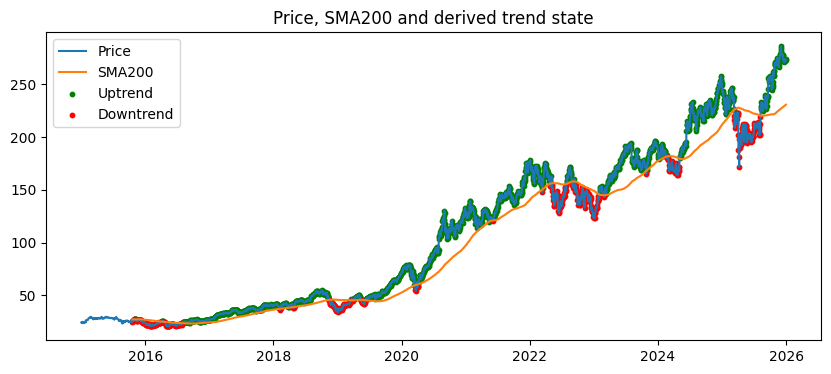

In [19]:
plt.figure(figsize=(10,4))
plt.plot(tmp["date"], tmp["adj_close"], label="Price")
plt.plot(tmp["date"], tmp["sma_200"], label="SMA200")

up = tmp["trend_state"] == 1
down = tmp["trend_state"] == 0

plt.scatter(tmp.loc[up, "date"], tmp.loc[up, "adj_close"], color="green", s=10, label="Uptrend")
plt.scatter(tmp.loc[down, "date"], tmp.loc[down, "adj_close"], color="red", s=10, label="Downtrend")

plt.legend()
plt.title("Price, SMA200 and derived trend state")
plt.show()

## Save Engineered Dataset

The engineered dataset is saved as a separate Parquet artifact for downstream target construction and modeling.

In [16]:
df_feat.to_parquet(OUT_FEAT_PATH, index=False)
print("Saved:", OUT_FEAT_PATH)

Saved: ../data/processed/financial_database_features.parquet
